<a href="https://colab.research.google.com/github/ACM-BRIN/peatland-fire-prediction/blob/main/Code_Pinang.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Library

In [ ]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from datetime import datetime, timedelta

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

import lightgbm as lgbm

from tensorflow import keras
from tensorflow.keras.optimizers import Adam
from keras import Model, Sequential
from keras.layers import Dense, Dropout
from keras.losses import MeanSquaredError

!pip3 install ann_visualizer
from ann_visualizer.visualize import ann_viz

!pip install shap
import shap

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
  Preparing metadata (setup.py) ... done
  Created wheel for ann_visualizer: filename=ann_visualizer-2.5-py3-none-any.whl size=4168 sha256=f70f0a0b28044a18a4f9a4df95b33600aae63a2c2fdf7e759e0ec208b1246b1a
  Stored in directory: /root/.cache/pip/wheels/4b/ef/77/9b8c4ae2f9a11de19957b80bc5c684accd99114bb8dc6b374c
Successfully built ann_visualizer
Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 575.9/575.9 KB 9.3 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Helper Function

In [ ]:
pair = [['pcp','rainfall','mm'],  ['t2m','near surface temperature','deg C'],
        ['rh','relative humidity','%'], ['ws','wind speed','m/s'],
        ['s_temp','soil temperature','deg C'], ['s_moist','soil moisture','%'], ['gwl','ground water level','cm'],
        ['hotspot','hotspot','spot'], ['emission','emission','g C/m^2']]

col_unit = pd.DataFrame(pair, columns=['Column','Aliases','Unit']).set_index('Column')

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.size'] = 30
plt.rcParams['axes.linewidth'] = 2
plt.rcParams['xtick.direction'],plt.rcParams['xtick.major.size'],plt.rcParams['xtick.major.width']='in',15,5
plt.rcParams['ytick.direction'],plt.rcParams['ytick.major.size'],plt.rcParams['ytick.major.width']='in',15,5
plt.rcParams['lines.linewidth']=3

def wmi(atribut, column, case): #--> Window Mean Interpolation
    if case == 1 : # --> (Nan/(will be replace), int1, int2, int3, int4, int5, int6)
      convert = atribut.loc[t + timedelta(days=1) : t + timedelta(days=6), column].mean()

    elif case == 2 : # --> (int1, int2, int3, Nan/(will be replace), int4, int5, int6)
      dtindex = pd.date_range(start= t - timedelta(days=3), end = t + timedelta(days=3), freq='d').delete(3)
      convert = atribut.loc[dtindex,column].mean()

    elif case == 3 : # --> (int1, int2, int3, int4, int5, int6,  Nan/(will be replace))
      convert = atribut.loc[t - timedelta(days=6) : t - timedelta(days=1),column].mean()

    return convert

def scale_predictor(X_train, X_test):
    scaler_x = MinMaxScaler()
    X_train_scaled = scaler_x.fit_transform(X_train)
    X_test_scaled = scaler_x.transform(X_test)
    return X_train_scaled, X_test_scaled

# Creating model using the Sequential in tensorflow
def build_nn(X_train):
    model = Sequential()

    model.add(Dense(X_train.shape[1]+100, activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(X_train.shape[1]+100, activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(X_train.shape[1]+100, activation='relu'))
    model.add(Dropout(0.2))

    model.add(Dense(y_train.shape[1], activation='linear'))

    model.compile(optimizer=Adam(learning_rate=0.01), loss='mean_squared_error', metrics = ['mse'])
    return model

def fit_nn(model, X_train):
    early_stop = keras.callbacks.EarlyStopping(monitor = 'val_loss', patience = 15)
    history = model.fit(X_train, y_train, epochs = 100,
                        validation_split = 0.2, batch_size = 256,
                        shuffle = False, callbacks = [early_stop])
    return history

def plot_history(history):
    plt.figure(figsize=(15, 6))
    plt.plot(history.history['loss'], label='Train loss')
    plt.plot(history.history['val_loss'], label='validation loss')
    plt.legend(loc='upper right')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')

def convert(y_pred):
    for i in range (len(y_pred)):
        if y_pred[i,0] < 0 :
            y_pred[i,0]  = 0
        else :
            y_pred[i,0] = round(y_pred[i,0])

        if y_pred[i,1] < 0 :
            y_pred[i,1]  = 0
    return(y_pred)

def plot_experiment(y_test, y_pred_1, y_pred_2, y_pred_3):
    fig, ax = plt.subplots(2, figsize=(16,16))
    ax[0].plot(y_test[:,0], linewidth=6, label='Actual')
    ax[0].plot(y_pred_1[:,0], '-o', label='Meteorological')
    ax[0].plot(y_pred_2[:,0], '-*', label='Hydrological')
    ax[0].plot(y_pred_3[:,0], '-x', label='All')
    ax[0].set(ylabel='Hotspot')
    ax[0].legend(fontsize = 20, loc = 'upper right')
    ax[0].set_title('(a)')

    ax[1].plot(y_test[:,1], linewidth=6, label='Actual')
    ax[1].plot(y_pred_1[:,1], '-o', label='Meteorological')
    ax[1].plot(y_pred_2[:,1], '-*', label='Hydrological')
    ax[1].plot(y_pred_3[:,1], '-x', label='All')
    ax[1].set(xlabel='Sample', ylabel='Emission (g C/m^2)')
    ax[1].set_title('(b)')

def evaluate(y_test, y_pred):
    mae_hotspot = round(mean_absolute_error(y_test[:,0], y_pred[:,0]), 2)
    nrmse_hotspot = round(mean_squared_error(y_test[:,0], y_pred[:,0], squared=False)/(max(y_test[:,0])-min(y_test[:,0])), 2)
    cc_hotspot = round(np.corrcoef(y_test[:,0], y_pred[:,0])[0][1], 2)

    mae_emission = round(mean_absolute_error(y_test[:,1], y_pred[:,1]), 2)
    nrmse_emission = round(mean_squared_error(y_test[:,1], y_pred[:,1], squared=False)/(max(y_test[:,1])-min(y_test[:,1])), 2)
    cc_emission = round(np.corrcoef(y_test[:,1], y_pred[:,1])[0][1], 2)

    metrics = {'':['Hotspot','Emission'],
               'MAE': [mae_hotspot, mae_emission],
               'NRMSE':[nrmse_hotspot, nrmse_emission],
               'CC':[cc_hotspot, cc_emission]}

    metrics_table = pd.DataFrame(metrics).set_index('')
    return(metrics_table)

# Step 1 : Read and Explore Data

In [ ]:
# Read File
raw_gabungan = pd.read_excel('drive/MyDrive/Pemodelan dan Simulasi/Kegiatan_RP_PPT/Data/Data gabungan.xlsx',
                         sheet_name = 'Pinang', parse_dates = ['Date'], index_col = 'Date')
raw_hotspot = pd.read_excel('drive/MyDrive/Pemodelan dan Simulasi/Kegiatan_RP_PPT/Data/Data_hotspot.xlsx',
                         sheet_name = 'Pinang', parse_dates = ['Date'], index_col = 'Date')
start = '2019-01-01'
end = '2019-10-31'
raw = raw_gabungan[start:end].join(raw_hotspot)
raw['Hotspot'] = raw['Hotspot'].fillna(0)

raw['ws'] = (raw['uw']**2 + raw['vw']**2)**(1/2)

df = raw[['curah_hujan','t2m','rh','ws','soil_temperature','soil_moisture','tma','Hotspot','daily_emission']]
df.columns = ['pcp','t2m','rh','ws','s_temp','s_moist','gwl','hotspot','emission']

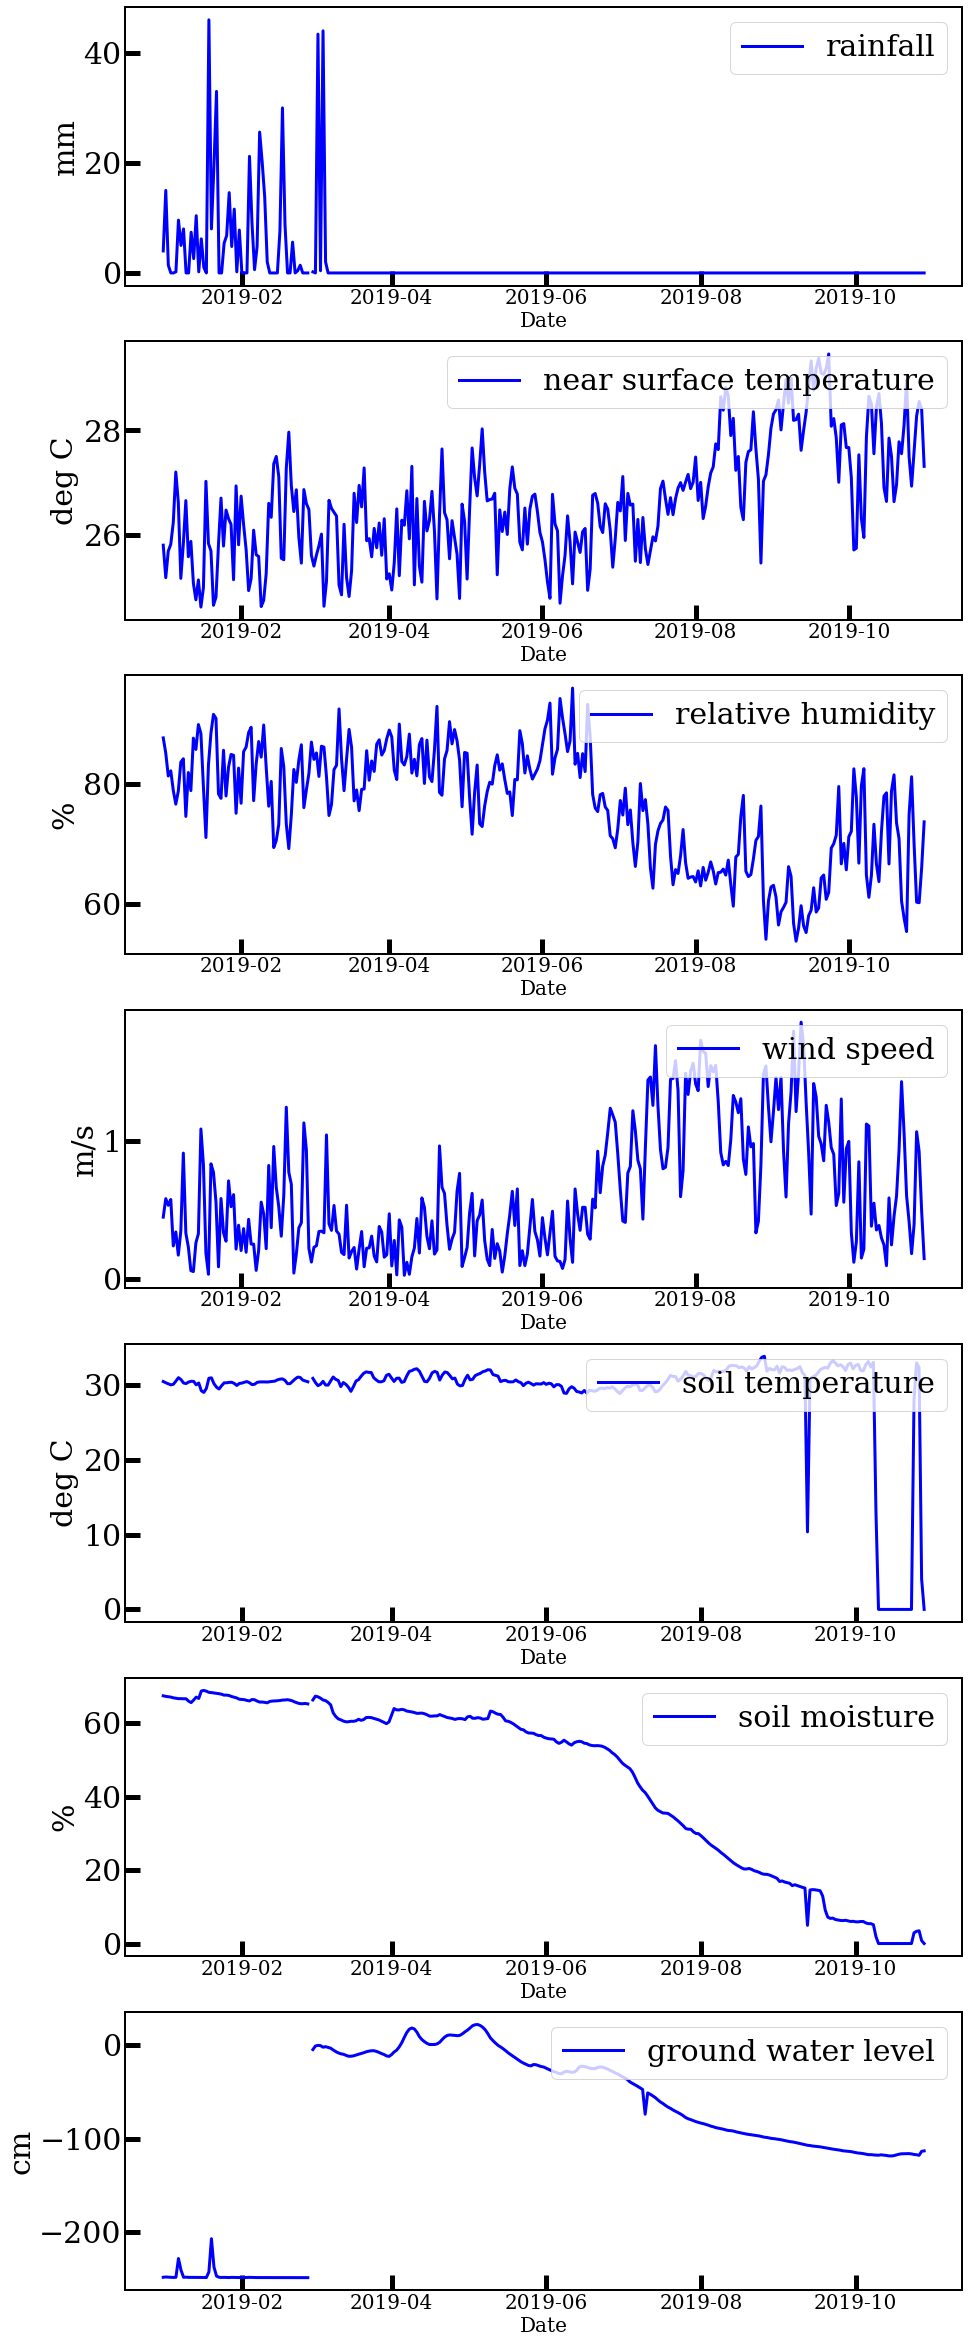

In [ ]:
fig, axs = plt.subplots(7, 1, figsize=(15,42))

for i, ax in enumerate(axs.flat):
    ax.plot(df.iloc[:,i], color ='blue', label=col_unit.loc[df.columns[i], 'Aliases'])
    ax.set_xticks(pd.date_range((datetime.strptime(start, '%Y-%m-%d')+ pd.DateOffset(months=1)).strftime('%Y-%m-%d'),end , freq='2M')-pd.offsets.MonthBegin(1))
    ax.set_xticklabels((pd.date_range((datetime.strptime(start, '%Y-%m-%d')+ pd.DateOffset(months=1)).strftime('%Y-%m-%d'),end , freq='2M')-pd.offsets.MonthBegin(1)).strftime('%Y-%m'),
                       fontsize=20)

    ax.set_xlabel('Date', fontsize = 20)
    ax.set_ylabel(col_unit.loc[df.columns[i], 'Unit'])
    ax.legend(loc = 'upper right')

In [ ]:
# Descriptive statistics for each column
df.describe().round(4)

,pcp,t2m,rh,ws,s_temp,s_moist,gwl,hotspot,emission
count,300.0000,304.0000,304.0000,304.0000,300.0000,300.0000,300.0000,304.0000,304.0000
mean,1.5660,26.6219,76.3967,0.6294,29.0850,44.7236,-88.5607,0.4178,7.0729
std,5.9994,1.1044,9.5115,0.4511,7.1108,23.1600,88.3951,1.7836,26.2490
min,0.0000,24.6217,53.8346,0.0277,0.0000,0.0000,-248.3000,0.0000,0.0000
25%,0.0000,25.8246,68.9785,0.2518,29.9887,21.7608,-116.4750,0.0000,0.0000
50%,0.0000,26.5236,78.3796,0.5040,30.5180,56.0460,-80.4500,0.0000,0.0000
75%,0.0000,27.3031,84.0376,0.9382,31.6512,63.0608,-11.9000,0.0000,0.0000
max,46.0000,29.4643,95.8820,1.8588,33.8290,68.9080,21.5000,19.0000,255.5921


In [ ]:
df.corr(method='pearson')

,pcp,t2m,rh,ws,s_temp,s_moist,gwl,hotspot,emission
pcp,1.000000,-0.260331,0.246066,-0.135721,0.046858,0.251137,-0.325893,-0.061771,-0.070863
t2m,-0.260331,1.000000,-0.823004,0.441319,-0.166218,-0.688312,-0.041904,0.312501,0.341782
rh,0.246066,-0.823004,1.000000,-0.741187,0.126761,0.727816,0.102481,-0.375704,-0.417554
ws,-0.135721,0.441319,-0.741187,1.000000,0.029744,-0.518418,-0.093847,0.330623,0.390810
s_temp,0.046858,-0.166218,0.126761,0.029744,1.000000,0.397561,0.079406,-0.037904,-0.024576
s_moist,0.251137,-0.688312,0.727816,-0.518418,0.397561,1.000000,0.009208,-0.323947,-0.339067
gwl,-0.325893,-0.041904,0.102481,-0.093847,0.079406,0.009208,1.000000,-0.045693,-0.036755
hotspot,-0.061771,0.312501,-0.375704,0.330623,-0.037904,-0.323947,-0.045693,1.000000,0.686160
emission,-0.070863,0.341782,-0.417554,0.390810,-0.024576,-0.339067,-0.036755,0.686160,1.000000


# Step 2 : Data Pre-Processing

## Handling Error and Missing Values

Interpolate Error and Missing Values using Window Mean Interpolation

In [ ]:
# gwl
for t in reversed(pd.date_range(start='2019-01-01', end ='2019-02-28', freq='d')):
    df.loc[t]['gwl'] = round(wmi(df, 'gwl', 1), 3)

for t in pd.date_range(start='2019-07-10', end ='2019-07-10', freq='d'):
    df.loc[t]['gwl'] = round(wmi(df, 'gwl', 2), 3)

for t in pd.date_range(start='2019-10-29', end ='2019-10-31', freq='d'):
    df.loc[t]['gwl'] = round(wmi(df, 'gwl', 3), 3)

# s_moist and s_temp + pcp
for t in pd.date_range(start='2019-09-12', end ='2019-09-12', freq='d'):
    df.loc[t]['s_temp'] = round(wmi(df, 's_temp', 2), 3)

for column in ['pcp', 's_moist', 's_temp']:
  for t in pd.date_range(start='2019-02-28', end ='2019-02-28', freq='d'):
    df.loc[t][column] = round(wmi(df, column, 2), 3)

  for t in pd.date_range(start='2019-10-09', end ='2019-10-24', freq='d'):
    df.loc[t][column] = round(wmi(df, column, 3), 3)

  for t in pd.date_range(start='2019-10-27', end ='2019-10-31', freq='d'):
    df.loc[t][column] = round(wmi(df, column, 3), 3)

In [ ]:
# Check missing values
df.isnull().sum()

pcp         0
t2m         0
rh          0
ws          0
s_temp      0
s_moist     0
gwl         0
hotspot     0
emission    0
dtype: int64

## Final Dataset

The Dataset after interpolate

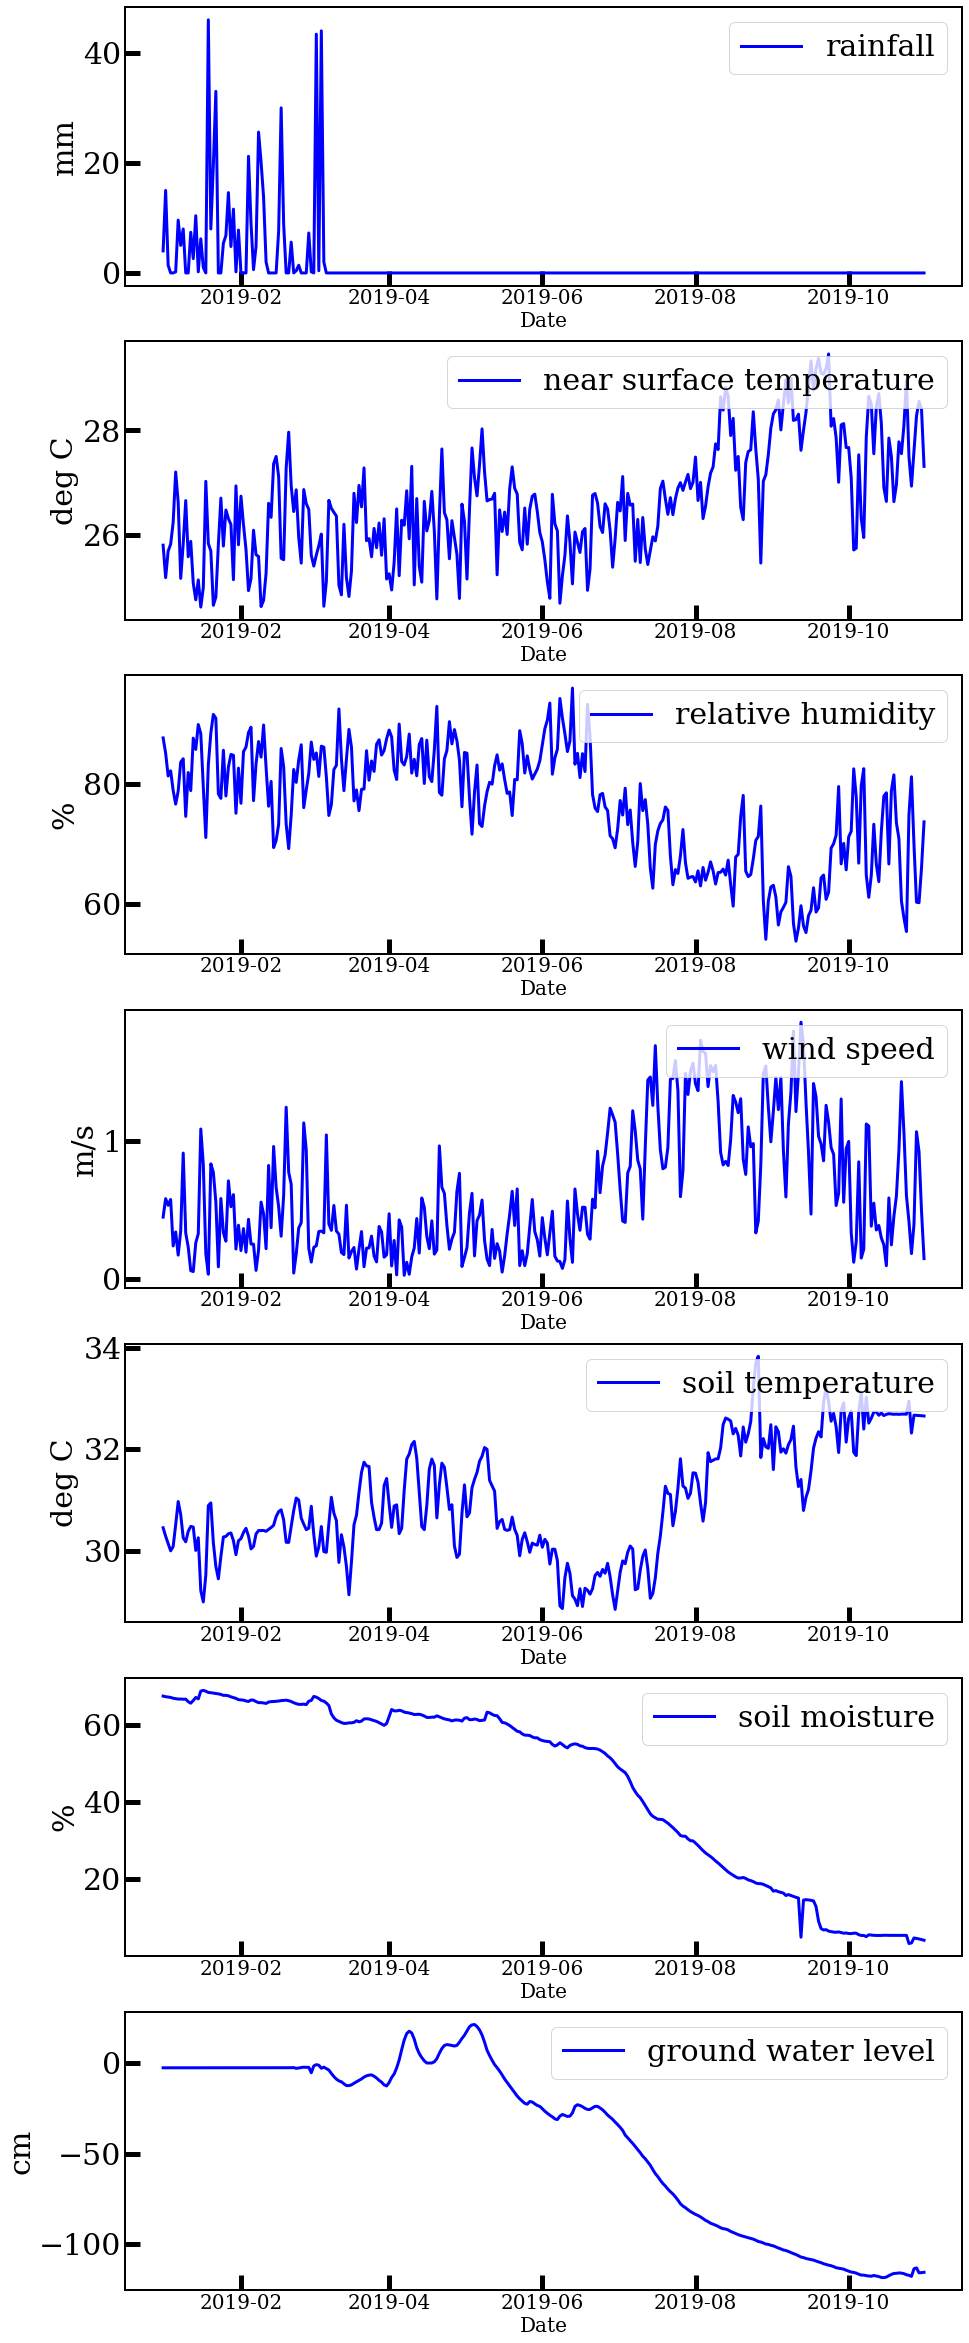

In [ ]:
fig, axs = plt.subplots(7, 1, figsize=(15,42))

for i, ax in enumerate(axs.flat):
    ax.plot(df.iloc[:,i], color ='blue', label=col_unit.loc[df.columns[i], 'Aliases'])
    ax.set_xticks(pd.date_range((datetime.strptime(start, '%Y-%m-%d')+ pd.DateOffset(months=1)).strftime('%Y-%m-%d'),end , freq='2M')-pd.offsets.MonthBegin(1))
    ax.set_xticklabels((pd.date_range((datetime.strptime(start, '%Y-%m-%d')+ pd.DateOffset(months=1)).strftime('%Y-%m-%d'),end , freq='2M')-pd.offsets.MonthBegin(1)).strftime('%Y-%m'),
                       fontsize=20)

    ax.set_xlabel('Date', fontsize = 20)
    ax.set_ylabel(col_unit.loc[df.columns[i], 'Unit'])
    ax.legend(loc = 'upper right')

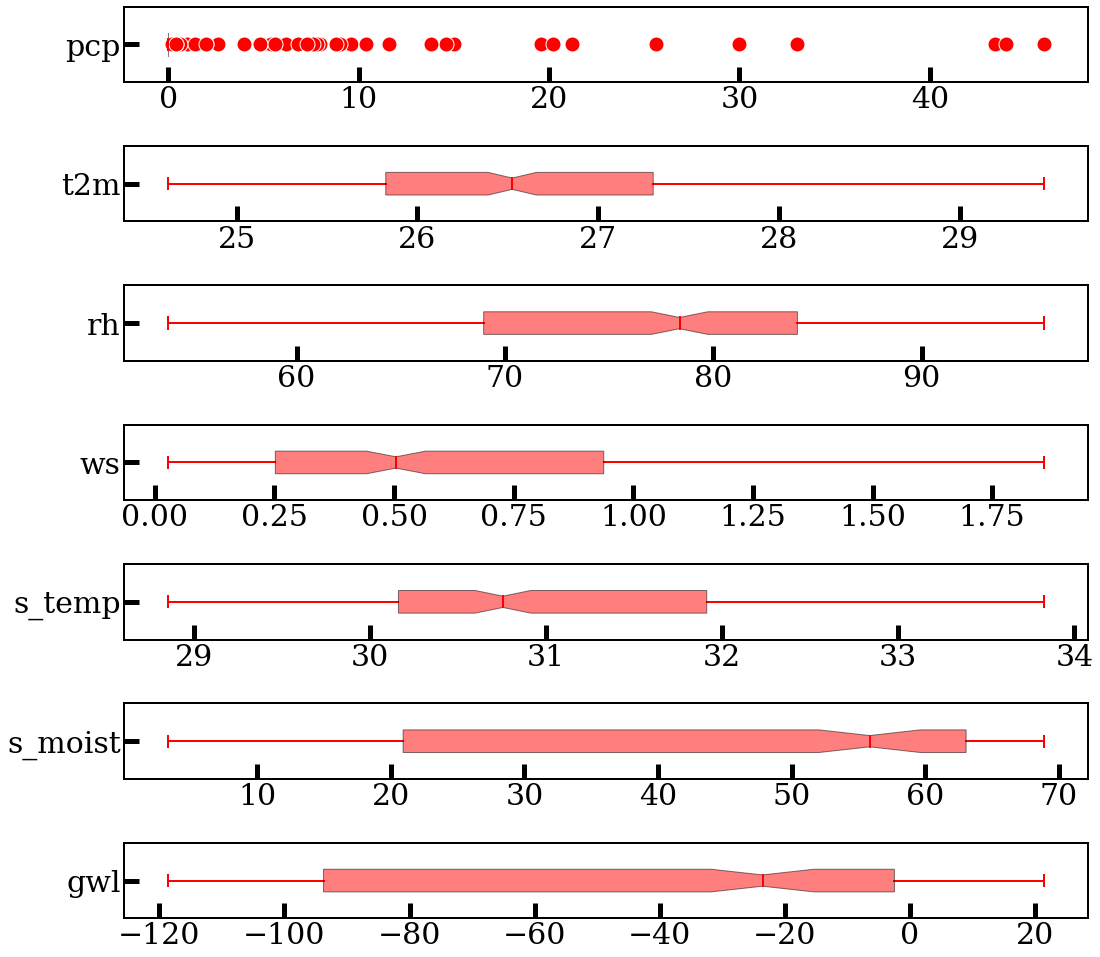

In [ ]:
#Creating subplot of each column with its own scale
red_circle = dict(markerfacecolor='red', marker='o', markeredgecolor='white')

fig, axs = plt.subplots(len(df.columns)-2, 1, figsize=(16,14))
for i, ax in enumerate(axs.flat):
    ax.boxplot(df.iloc[:,i], widths=0.3, vert=False, notch=True, patch_artist=True,
               boxprops=dict(facecolor='red', alpha=0.5), capprops=dict(color='red', linewidth=2), whiskerprops=dict(color='red', linewidth=2),
               flierprops=dict(markerfacecolor='red', marker='o', markeredgecolor='white', markersize= 15),
               medianprops=dict(color='red', linewidth=2)
            )
    ax.set_yticklabels([df.columns[i]])
plt.tight_layout()

(737211.0, 737363.0)

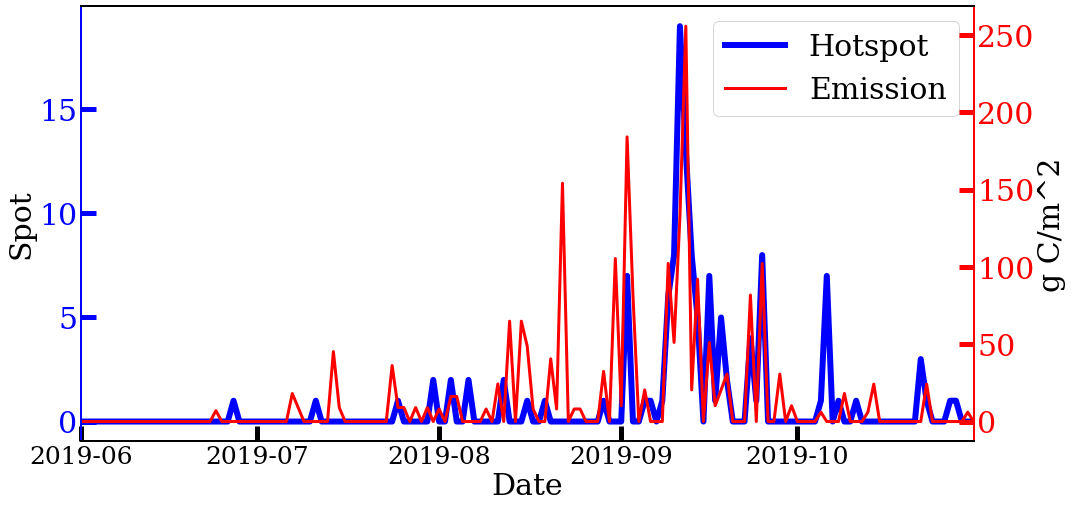

In [ ]:
fig, ax1 = plt.subplots(figsize=(16,8))
ax2 = ax1.twinx()

start='2019-06-01'
end='2019-10-31'

ax1.set_xticks(pd.date_range(start,end , freq='1M')-pd.offsets.MonthBegin(1))
ax1.set_xticklabels((pd.date_range(start,end , freq='1M')-pd.offsets.MonthBegin(1)).strftime('%Y-%m'),
                       fontsize=25)
ax2.set_xticks(pd.date_range(start,end , freq='1M')-pd.offsets.MonthBegin(1))
ax2.set_xticklabels((pd.date_range(start,end , freq='1M')-pd.offsets.MonthBegin(1)).strftime('%Y-%m'),
                       fontsize=25)

ax2.spines['left'].set_color('blue')
ax2.spines['right'].set_color('red')

ax1.tick_params(axis='y', colors='blue')
ax2.tick_params(axis='y', colors='red')

lns1=ax1.plot(df['hotspot'], '-b', label='Hotspot', linewidth=6)
lns2=ax2.plot(df['emission'], '-r', label='Emission')

lns = lns1+lns2
labs = [l.get_label() for l in lns]
ax1.legend(lns, labs, loc=0)

ax1.set_xlabel('Date')
ax1.set_ylabel('Spot')
ax2.set_ylabel('g C/m^2')

ax1.set_xlim(datetime.strptime(start, '%Y-%m-%d'),datetime.strptime(end, '%Y-%m-%d'))

In [ ]:
# Descriptive statistics for each column
df.describe().round(4)

,pcp,t2m,rh,ws,s_temp,s_moist,gwl,hotspot,emission
count,304.0000,304.0000,304.0000,304.0000,304.0000,304.0000,304.0000,304.0000,304.0000
mean,1.5693,26.6219,76.3967,0.6294,30.9810,44.6949,-41.8849,0.4178,7.0729
std,5.9707,1.1044,9.5115,0.4511,1.1183,22.8421,46.8329,1.7836,26.2490
min,0.0000,24.6217,53.8346,0.0277,28.8550,3.3210,-118.6000,0.0000,0.0000
25%,0.0000,25.8246,68.9785,0.2518,30.1628,20.9130,-93.7500,0.0000,0.0000
50%,0.0000,26.5236,78.3796,0.5040,30.7560,55.8425,-23.5500,0.0000,0.0000
75%,0.0000,27.3031,84.0376,0.9382,31.9130,63.0608,-2.4530,0.0000,0.0000
max,46.0000,29.4643,95.8820,1.8588,33.8290,68.9080,21.5000,19.0000,255.5921


In [ ]:
df.corr(method='pearson')

,pcp,t2m,rh,ws,s_temp,s_moist,gwl,hotspot,emission
pcp,1.000000,-0.261039,0.248203,-0.137141,-0.146730,0.256573,0.222822,-0.061764,-0.071055
t2m,-0.261039,1.000000,-0.823004,0.441319,0.687799,-0.696206,-0.669037,0.312501,0.341782
rh,0.248203,-0.823004,1.000000,-0.741187,-0.531827,0.737200,0.743135,-0.375704,-0.417554
ws,-0.137141,0.441319,-0.741187,1.000000,0.202648,-0.519741,-0.553320,0.330623,0.390810
s_temp,-0.146730,0.687799,-0.531827,0.202648,1.000000,-0.716047,-0.656077,0.186854,0.233727
s_moist,0.256573,-0.696206,0.737200,-0.519741,-0.716047,1.000000,0.984710,-0.322966,-0.340394
gwl,0.222822,-0.669037,0.743135,-0.553320,-0.656077,0.984710,1.000000,-0.319846,-0.338767
hotspot,-0.061764,0.312501,-0.375704,0.330623,0.186854,-0.322966,-0.319846,1.000000,0.686160
emission,-0.071055,0.341782,-0.417554,0.390810,0.233727,-0.340394,-0.338767,0.686160,1.000000


## Prepare Predictor and Target

Determine the variables that will be used as predictors in the experimental scheme

In [ ]:
pred_meteorological = ['pcp','t2m','rh','ws']
pred_hydrological = ['s_temp','s_moist','gwl']
pred_all = pred_meteorological + pred_hydrological
target = ['hotspot','emission']

In [ ]:
X_1 = df[pred_meteorological]
X_2 = df[pred_hydrological]
X_3 = df[pred_all]
y = df[target]

print(X_1.shape)
print(X_2.shape)
print(X_3.shape)
print(y.shape)

(304, 4)
(304, 3)
(304, 7)
(304, 2)


In [ ]:
X_train_1, X_test_1, y_train, y_test = train_test_split(X_1, y, test_size = 0.2, random_state=42)
X_train_2, X_test_2, y_train, y_test = train_test_split(X_2, y, test_size = 0.2, random_state=42)
X_train_3, X_test_3, y_train, y_test = train_test_split(X_3, y, test_size = 0.2, random_state=42)

In [ ]:
X_train_1, X_test_1 = scale_predictor(X_train_1, X_test_1)
X_train_2, X_test_2 = scale_predictor(X_train_2, X_test_2)
X_train_3, X_test_3 = scale_predictor(X_train_3, X_test_3)

y_train = np.array(y_train)
y_test = np.array(y_test)

print('X_train_1.shape:', X_train_1.shape, ' | X_test_1.shape:', X_test_1.shape)
print('X_train_2.shape:', X_train_2.shape, ' | X_test_2.shape:', X_test_2.shape)
print('X_train_3.shape:', X_train_3.shape, ' | X_test_3.shape:', X_test_3.shape)
print('y_train.shape: ', y_train.shape, ' | y_test.shape: ', y_test.shape)

X_train_1.shape: (243, 4)  | X_test_1.shape: (61, 4)
X_train_2.shape: (243, 3)  | X_test_2.shape: (61, 3)
X_train_3.shape: (243, 7)  | X_test_3.shape: (61, 7)
y_train.shape:  (243, 2)  | y_test.shape:  (61, 2)


# Step 3 : Experiment

Find the best predictor for each Method (Random Forest, Light Gradient Boosted Machine, and Neural Network)

## RF

In [ ]:
from pprint import pprint

from sklearn.model_selection import RandomizedSearchCV
# Method of selecting samples for training each tree
bootstrap = [True, False]
# Maximum number of levels in tree
max_depth = [int(x) for x in np.linspace(10, 100, num = 10)]
max_depth.append(None)
# Number of features to consider at every split
max_features = ['auto', 'sqrt']
# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]
# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]
# Number of trees in random forest
n_estimators = [int(x) for x in np.linspace(start = 200, stop = 2000, num = 10)]

# Create the random grid
random_grid = {'estimator__bootstrap': bootstrap,
               'estimator__max_depth': max_depth,
               'estimator__max_features': max_features,
               'estimator__min_samples_leaf': min_samples_leaf,
               'estimator__min_samples_split': min_samples_split,
               'estimator__n_estimators': n_estimators
               }
pprint(random_grid)

{'estimator__bootstrap': [True, False],
 'estimator__max_depth': [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, None],
 'estimator__max_features': ['auto', 'sqrt'],
 'estimator__min_samples_leaf': [1, 2, 4],
 'estimator__min_samples_split': [2, 5, 10],
 'estimator__n_estimators': [200,
                             400,
                             600,
                             800,
                             1000,
                             1200,
                             1400,
                             1600,
                             1800,
                             2000]}


### Exp 1

In [ ]:
rf_base_1 = MultiOutputRegressor(RandomForestRegressor(random_state = 42))
rf_base_1.fit(X_train_1, y_train)
pred_rf_base_1 = convert(rf_base_1.predict(X_test_1))

base_accuracy_1 = evaluate(y_test, pred_rf_base_1)['MAE'].mean()
evaluate(y_test, pred_rf_base_1)

,MAE,NRMSE,CC
,,,
Hotspot,0.87,0.15,0.26
Emission,10.85,0.18,0.51


In [ ]:
from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(rf_base_1.get_params())

Parameters currently in use:

{'estimator': RandomForestRegressor(random_state=42),
 'estimator__bootstrap': True,
 'estimator__ccp_alpha': 0.0,
 'estimator__criterion': 'squared_error',
 'estimator__max_depth': None,
 'estimator__max_features': 'auto',
 'estimator__max_leaf_nodes': None,
 'estimator__max_samples': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__n_estimators': 100,
 'estimator__n_jobs': None,
 'estimator__oob_score': False,
 'estimator__random_state': 42,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'n_jobs': None}


In [ ]:
# Use the random grid to search for best hyperparameters
# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations, and use all available cores
rf_random_1 = RandomizedSearchCV(estimator = MultiOutputRegressor(RandomForestRegressor()), param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)

In [ ]:
# Fit the random search model
rf_random_1.fit(X_train_1, y_train)

rf_random_1.best_params_

Fitting 3 folds for each of 100 candidates, totalling 300 fits


{'estimator__n_estimators': 1200,
 'estimator__min_samples_split': 10,
 'estimator__min_samples_leaf': 1,
 'estimator__max_features': 'sqrt',
 'estimator__max_depth': 40,
 'estimator__bootstrap': True}

In [ ]:
best_random_1 = rf_random_1.best_estimator_
pred_rf_random_1 = convert(best_random_1.predict(X_test_1))

random_accuracy_1 = evaluate(y_test, pred_rf_random_1)['MAE'].mean()
evaluate(y_test, pred_rf_random_1)

,MAE,NRMSE,CC
,,,
Hotspot,0.79,0.14,0.51
Emission,11.00,0.17,0.55


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_1 - random_accuracy_1) / base_accuracy_1))

Improvement : MAE.mean() decreased by -0.60%


In [ ]:
from sklearn.model_selection import GridSearchCV
# Create the parameter grid based on the results of random search
param_grid = {
    'estimator__bootstrap': [True],
    'estimator__max_depth': [None],
    'estimator__max_features': ['auto'],
    'estimator__min_samples_leaf': [1],
    'estimator__min_samples_split': [2],
    'estimator__n_estimators': [100, 200, 300]
}

# Instantiate the grid search model
grid_search_1 = GridSearchCV(estimator = MultiOutputRegressor(RandomForestRegressor()), param_grid = param_grid,
                          cv = 3, n_jobs = -1, verbose = 2)

In [ ]:
# Fit the grid search to the data
grid_search_1.fit(X_train_1, y_train)

grid_search_1.best_params_

Fitting 3 folds for each of 3 candidates, totalling 9 fits


{'estimator__bootstrap': True,
 'estimator__max_depth': None,
 'estimator__max_features': 'auto',
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__n_estimators': 200}

In [ ]:
model_rf_1 = grid_search_1.best_estimator_
pred_rf_1 = convert(model_rf_1.predict(X_test_1))

grid_accuracy_1 = evaluate(y_test, pred_rf_1)['MAE'].mean()
evaluate(y_test, pred_rf_1)

,MAE,NRMSE,CC
,,,
Hotspot,0.82,0.14,0.44
Emission,10.54,0.18,0.52


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_1 - grid_accuracy_1) / base_accuracy_1))

Improvement : MAE.mean() decreased by 3.07%


### Exp 2

In [ ]:
rf_base_2 = MultiOutputRegressor(RandomForestRegressor(random_state = 42))
rf_base_2.fit(X_train_2, y_train)
pred_rf_base_2 = convert(rf_base_2.predict(X_test_2))

base_accuracy_2 = evaluate(y_test, pred_rf_base_2)['MAE'].mean()
evaluate(y_test, pred_rf_base_2)

,MAE,NRMSE,CC
,,,
Hotspot,0.62,0.12,0.82
Emission,10.02,0.14,0.75


In [ ]:
from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(rf_base_2.get_params())

Parameters currently in use:

{'estimator': RandomForestRegressor(random_state=42),
 'estimator__bootstrap': True,
 'estimator__ccp_alpha': 0.0,
 'estimator__criterion': 'squared_error',
 'estimator__max_depth': None,
 'estimator__max_features': 'auto',
 'estimator__max_leaf_nodes': None,
 'estimator__max_samples': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__n_estimators': 100,
 'estimator__n_jobs': None,
 'estimator__oob_score': False,
 'estimator__random_state': 42,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'n_jobs': None}


In [ ]:
# Use the random grid to search for best hyperparameters
# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations, and use all available cores
rf_random_2 = RandomizedSearchCV(estimator = MultiOutputRegressor(RandomForestRegressor()), param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)

In [ ]:
# Fit the random search model
rf_random_2.fit(X_train_2, y_train)

rf_random_2.best_params_

Fitting 3 folds for each of 100 candidates, totalling 300 fits


{'estimator__n_estimators': 200,
 'estimator__min_samples_split': 2,
 'estimator__min_samples_leaf': 1,
 'estimator__max_features': 'auto',
 'estimator__max_depth': 50,
 'estimator__bootstrap': True}

In [ ]:
best_random_2 = rf_random_2.best_estimator_
pred_rf_random_2 = convert(best_random_2.predict(X_test_2))

random_accuracy_2 = evaluate(y_test, pred_rf_random_2)['MAE'].mean()
evaluate(y_test, pred_rf_random_2)

,MAE,NRMSE,CC
,,,
Hotspot,0.66,0.12,0.81
Emission,10.07,0.14,0.77


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_2 - random_accuracy_2) / base_accuracy_2))

Improvement : MAE.mean() decreased by -0.85%


In [ ]:
from sklearn.model_selection import GridSearchCV
# Create the parameter grid based on the results of random search
param_grid = {
    'estimator__bootstrap': [True],
    'estimator__max_depth': [None],
    'estimator__max_features': [2],
    'estimator__min_samples_leaf': [1],
    'estimator__min_samples_split': [2],
    'estimator__n_estimators': [100]
}

# Instantiate the grid search model
grid_search_2 = GridSearchCV(estimator = MultiOutputRegressor(RandomForestRegressor()), param_grid = param_grid,
                          cv = 3, n_jobs = -1, verbose = 2)

In [ ]:
# Fit the grid search to the data
grid_search_2.fit(X_train_2, y_train)

grid_search_2.best_params_

Fitting 3 folds for each of 1 candidates, totalling 3 fits


{'estimator__bootstrap': True,
 'estimator__max_depth': None,
 'estimator__max_features': 2,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__n_estimators': 100}

In [ ]:
model_rf_2 = grid_search_2.best_estimator_
pred_rf_2 = convert(model_rf_2.predict(X_test_2))

grid_accuracy_2 = evaluate(y_test, pred_rf_2)['MAE'].mean()
evaluate(y_test, pred_rf_2)

,MAE,NRMSE,CC
,,,
Hotspot,0.64,0.12,0.85
Emission,9.34,0.15,0.68


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_2 - grid_accuracy_2) / base_accuracy_2))

Improvement : MAE.mean() decreased by 6.20%


### Exp 3

In [ ]:
rf_base_3 = MultiOutputRegressor(RandomForestRegressor(random_state = 42))
rf_base_3.fit(X_train_3, y_train)
pred_rf_base_3 = convert(rf_base_3.predict(X_test_3))

base_accuracy_3 = evaluate(y_test, pred_rf_base_3)['MAE'].mean()
evaluate(y_test, pred_rf_base_3)

,MAE,NRMSE,CC
,,,
Hotspot,0.80,0.14,0.44
Emission,10.67,0.17,0.64


In [ ]:
from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(rf_base_3.get_params())

Parameters currently in use:

{'estimator': RandomForestRegressor(random_state=42),
 'estimator__bootstrap': True,
 'estimator__ccp_alpha': 0.0,
 'estimator__criterion': 'squared_error',
 'estimator__max_depth': None,
 'estimator__max_features': 'auto',
 'estimator__max_leaf_nodes': None,
 'estimator__max_samples': None,
 'estimator__min_impurity_decrease': 0.0,
 'estimator__min_samples_leaf': 1,
 'estimator__min_samples_split': 2,
 'estimator__min_weight_fraction_leaf': 0.0,
 'estimator__n_estimators': 100,
 'estimator__n_jobs': None,
 'estimator__oob_score': False,
 'estimator__random_state': 42,
 'estimator__verbose': 0,
 'estimator__warm_start': False,
 'n_jobs': None}


In [ ]:
# Use the random grid to search for best hyperparameters
# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations, and use all available cores
rf_random_3 = RandomizedSearchCV(estimator = MultiOutputRegressor(RandomForestRegressor()), param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)

In [ ]:
# Fit the random search model
rf_random_3.fit(X_train_3, y_train)

rf_random_3.best_params_

Fitting 3 folds for each of 100 candidates, totalling 300 fits


{'estimator__n_estimators': 1200,
 'estimator__min_samples_split': 10,
 'estimator__min_samples_leaf': 2,
 'estimator__max_features': 'sqrt',
 'estimator__max_depth': 100,
 'estimator__bootstrap': True}

In [ ]:
best_random_3 = rf_random_3.best_estimator_
pred_rf_random_3 = convert(best_random_3.predict(X_test_3))

random_accuracy_3 = evaluate(y_test, pred_rf_random_3)['MAE'].mean()
evaluate(y_test, pred_rf_random_3)

,MAE,NRMSE,CC
,,,
Hotspot,0.66,0.12,0.77
Emission,11.29,0.17,0.60


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_3 - random_accuracy_3) / base_accuracy_3))

Improvement : MAE.mean() decreased by -4.18%


In [ ]:
from sklearn.model_selection import GridSearchCV
# Create the parameter grid based on the results of random search
param_grid = {
    'bootstrap': [True],
    'max_depth': [None],
    'max_features': ['auto'],
    'min_samples_leaf': [1],
    'min_samples_split': [2],
    'n_estimators': [100, 200, 300]
}

# Instantiate the grid search model
grid_search_3 = GridSearchCV(estimator = RandomForestRegressor(), param_grid = param_grid,
                          cv = 3, n_jobs = -1, verbose = 2)

In [ ]:
# Fit the grid search to the data
grid_search_3.fit(X_train_3, y_train)

grid_search_3.best_params_

Fitting 3 folds for each of 3 candidates, totalling 9 fits


{'bootstrap': True,
 'max_depth': None,
 'max_features': 'auto',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

In [ ]:
model_rf_3 = grid_search_3.best_estimator_
pred_rf_3 = convert(model_rf_3.predict(X_test_3))

grid_accuracy_3 = evaluate(y_test, pred_rf_3)['MAE'].mean()
evaluate(y_test, pred_rf_3)

,MAE,NRMSE,CC
,,,
Hotspot,0.70,0.14,0.63
Emission,10.38,0.17,0.68


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_3 - grid_accuracy_3) / base_accuracy_3))

Improvement : MAE.mean() decreased by 3.40%


### Plot

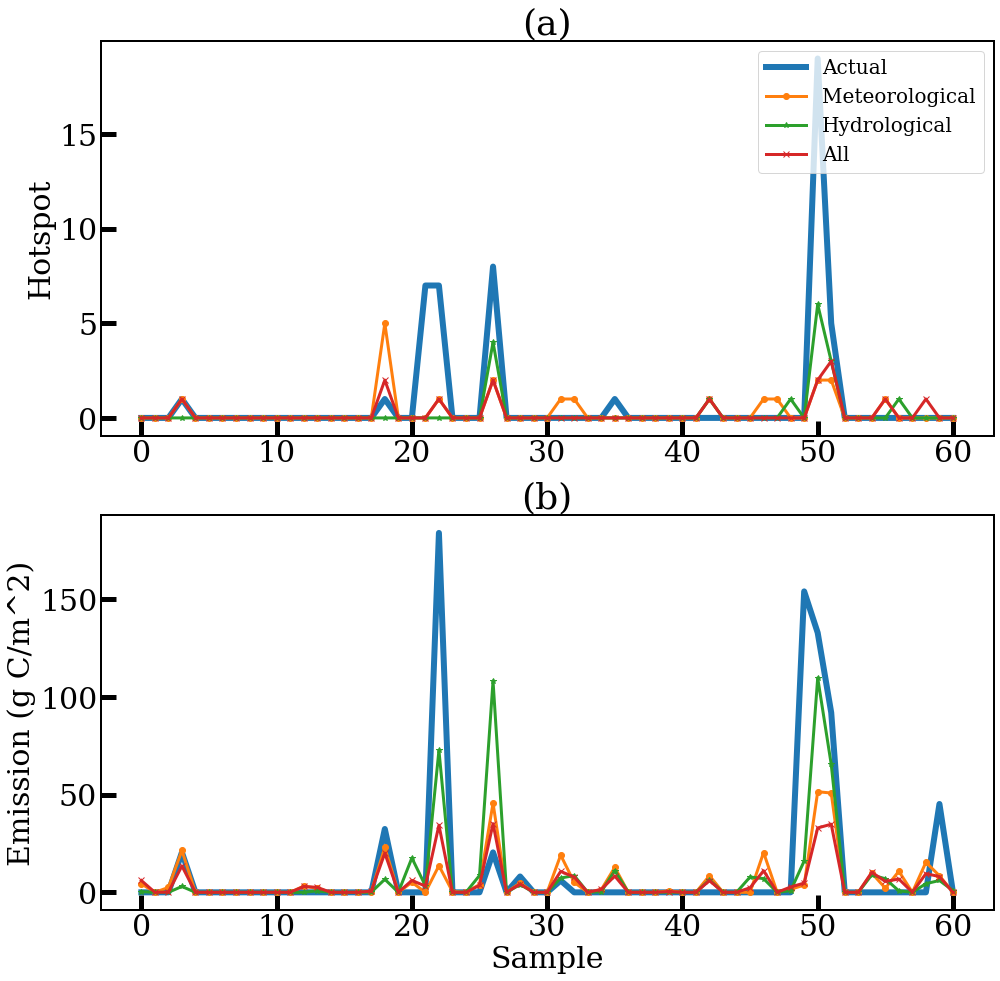

In [ ]:
plot_experiment(y_test, pred_rf_1, pred_rf_2, pred_rf_3)

In [ ]:
evaluate(y_test, pred_rf_1)

,MAE,NRMSE,CC
,,,
Hotspot,0.82,0.14,0.44
Emission,10.54,0.18,0.52


In [ ]:
evaluate(y_test, pred_rf_2)

,MAE,NRMSE,CC
,,,
Hotspot,0.64,0.12,0.85
Emission,9.34,0.15,0.68


In [ ]:
evaluate(y_test, pred_rf_3)

,MAE,NRMSE,CC
,,,
Hotspot,0.70,0.14,0.63
Emission,10.38,0.17,0.68


## LightGBM

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
# Boosting Type
boosting_type = ['gbdt', 'dart', 'goss']
# maximum depth of the tree
max_depth = [5,6,7,8,9,10,12]
# maximum number of leaves in one tree, main parameter to tune for a tree model
num_leaves = [int(x) for x in np.linspace(start = 20, stop = 300, num = 10)]
# Number of trees in lgbm
n_estimators = [int(x) for x in np.linspace(start = 100, stop = 1000, num = 10)]
# shrinkage rate, determine how fast the model can learn
learning_rate = [0.1, 0.01, 0.001]

# Create the random grid
random_grid = {'estimator__boosting_type': boosting_type,
               'estimator__max_depth': max_depth,
               'estimator__num_leaves': num_leaves,
               'estimator__n_estimators':n_estimators,
               'estimator__learning_rate': learning_rate
                }
pprint(random_grid)

{'estimator__boosting_type': ['gbdt', 'dart', 'goss'],
 'estimator__learning_rate': [0.1, 0.01, 0.001],
 'estimator__max_depth': [5, 6, 7, 8, 9, 10, 12],
 'estimator__n_estimators': [100, 200, 300, 400, 500, 600, 700, 800, 900, 1000],
 'estimator__num_leaves': [20, 51, 82, 113, 144, 175, 206, 237, 268, 300]}


### Exp 1

In [ ]:
lgbm_base_1 = MultiOutputRegressor(lgbm.LGBMRegressor())
lgbm_base_1.fit(X_train_1, y_train)
pred_lgbm_base_1 = convert(lgbm_base_1.predict(X_test_1))

base_accuracy_1 = evaluate(y_test, pred_lgbm_base_1)['MAE'].mean()
evaluate(y_test, pred_lgbm_base_1)

,MAE,NRMSE,CC
,,,
Hotspot,0.84,0.14,0.48
Emission,12.15,0.17,0.57


In [ ]:
from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(lgbm_base_1.get_params())

Parameters currently in use:

{'estimator': LGBMRegressor(),
 'estimator__boosting_type': 'gbdt',
 'estimator__class_weight': None,
 'estimator__colsample_bytree': 1.0,
 'estimator__importance_type': 'split',
 'estimator__learning_rate': 0.1,
 'estimator__max_depth': -1,
 'estimator__min_child_samples': 20,
 'estimator__min_child_weight': 0.001,
 'estimator__min_split_gain': 0.0,
 'estimator__n_estimators': 100,
 'estimator__n_jobs': -1,
 'estimator__num_leaves': 31,
 'estimator__objective': None,
 'estimator__random_state': None,
 'estimator__reg_alpha': 0.0,
 'estimator__reg_lambda': 0.0,
 'estimator__silent': True,
 'estimator__subsample': 1.0,
 'estimator__subsample_for_bin': 200000,
 'estimator__subsample_freq': 0,
 'n_jobs': None}


In [ ]:
# Use the random grid to search for best hyperparameters
# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations, and use all available cores
lgbm_random_1 = RandomizedSearchCV(estimator = MultiOutputRegressor(lgbm.LGBMRegressor()), param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)

In [ ]:
# Fit the random search model
lgbm_random_1.fit(X_train_1, y_train)

lgbm_random_1.best_params_

Fitting 3 folds for each of 100 candidates, totalling 300 fits


{'estimator__num_leaves': 175,
 'estimator__n_estimators': 400,
 'estimator__max_depth': 5,
 'estimator__learning_rate': 0.01,
 'estimator__boosting_type': 'dart'}

In [ ]:
best_random_1 = lgbm_random_1.best_estimator_
pred_lgbm_random_1 = convert(best_random_1.predict(X_test_1))

random_accuracy_1 = evaluate(y_test, pred_lgbm_random_1)['MAE'].mean()
evaluate(y_test, pred_lgbm_random_1)

,MAE,NRMSE,CC
,,,
Hotspot,0.74,0.14,0.58
Emission,11.32,0.18,0.54


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_1 - random_accuracy_1) / base_accuracy_1))

Improvement : MAE.mean() decreased by 7.16%


In [ ]:
from sklearn.model_selection import GridSearchCV
# Create the parameter grid based on the results of random search
param_grid = {'estimator__boosting_type': ['dart'],
              'estimator__max_depth': [7, 8, 9],
              'estimator__num_leaves': [100, 150, 200],
              'estimator__n_estimators': [200, 400, 600],
              'estimator__learning_rate': [0.01]
}
# Create a based model
# rf = RandomForestRegressor()
# Instantiate the grid search model
grid_search_1 = GridSearchCV(estimator = MultiOutputRegressor(lgbm.LGBMRegressor()), param_grid = param_grid,
                          cv = 3, n_jobs = -1, verbose = 2)

In [ ]:
# Fit the grid search to the data
grid_search_1.fit(X_train_1, y_train)

grid_search_1.best_params_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


{'estimator__boosting_type': 'dart',
 'estimator__learning_rate': 0.01,
 'estimator__max_depth': 7,
 'estimator__n_estimators': 400,
 'estimator__num_leaves': 100}

In [ ]:
model_lgbm_1 = grid_search_1.best_estimator_
pred_lgbm_1 = convert(model_lgbm_1.predict(X_test_1))

grid_accuracy_1 = evaluate(y_test, pred_lgbm_1)['MAE'].mean()
evaluate(y_test, pred_lgbm_1)

,MAE,NRMSE,CC
,,,
Hotspot,0.74,0.14,0.58
Emission,11.32,0.18,0.54


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_1 - grid_accuracy_1) / base_accuracy_1))

Improvement : MAE.mean() decreased by 7.16%


### Exp 2

In [ ]:
lgbm_base_2 = MultiOutputRegressor(lgbm.LGBMRegressor())
lgbm_base_2.fit(X_train_2, y_train)
pred_lgbm_base_2 = convert(lgbm_base_2.predict(X_test_2))

base_accuracy_2 = evaluate(y_test, pred_lgbm_base_2)['MAE'].mean()
evaluate(y_test, pred_lgbm_base_2)

,MAE,NRMSE,CC
,,,
Hotspot,0.64,0.12,0.81
Emission,10.51,0.16,0.76


In [ ]:
from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(lgbm_base_2.get_params())

Parameters currently in use:

{'estimator': LGBMRegressor(),
 'estimator__boosting_type': 'gbdt',
 'estimator__class_weight': None,
 'estimator__colsample_bytree': 1.0,
 'estimator__importance_type': 'split',
 'estimator__learning_rate': 0.1,
 'estimator__max_depth': -1,
 'estimator__min_child_samples': 20,
 'estimator__min_child_weight': 0.001,
 'estimator__min_split_gain': 0.0,
 'estimator__n_estimators': 100,
 'estimator__n_jobs': -1,
 'estimator__num_leaves': 31,
 'estimator__objective': None,
 'estimator__random_state': None,
 'estimator__reg_alpha': 0.0,
 'estimator__reg_lambda': 0.0,
 'estimator__silent': True,
 'estimator__subsample': 1.0,
 'estimator__subsample_for_bin': 200000,
 'estimator__subsample_freq': 0,
 'n_jobs': None}


In [ ]:
# Use the random grid to search for best hyperparameters
# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations, and use all available cores
lgbm_random_2 = RandomizedSearchCV(estimator = MultiOutputRegressor(lgbm.LGBMRegressor()), param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)

In [ ]:
# Fit the random search model
lgbm_random_2.fit(X_train_2, y_train)

lgbm_random_2.best_params_

Fitting 3 folds for each of 100 candidates, totalling 300 fits


{'estimator__num_leaves': 268,
 'estimator__n_estimators': 300,
 'estimator__max_depth': 8,
 'estimator__learning_rate': 0.01,
 'estimator__boosting_type': 'dart'}

In [ ]:
best_random_2 = lgbm_random_2.best_estimator_
pred_lgbm_random_2 = convert(best_random_2.predict(X_test_2))

random_accuracy_2 = evaluate(y_test, pred_lgbm_random_2)['MAE'].mean()
evaluate(y_test, pred_lgbm_random_2)

,MAE,NRMSE,CC
,,,
Hotspot,0.70,0.14,0.77
Emission,10.45,0.18,0.70


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_2 - random_accuracy_2) / base_accuracy_2))

Improvement : MAE.mean() decreased by 0.00%


In [ ]:
from sklearn.model_selection import GridSearchCV
# Create the parameter grid based on the results of random search
param_grid = {'estimator__boosting_type': ['dart'],
              'estimator__max_depth': [7, 8, 9],
              'estimator__num_leaves': [100, 150, 200],
              'estimator__n_estimators': [100, 200, 300],
              'estimator__learning_rate': [0.01]
}
# Create a based model
# rf = RandomForestRegressor()
# Instantiate the grid search model
grid_search_2 = GridSearchCV(estimator = MultiOutputRegressor(lgbm.LGBMRegressor()), param_grid = param_grid,
                          cv = 3, n_jobs = -1, verbose = 2)

In [ ]:
# Fit the grid search to the data
grid_search_2.fit(X_train_2, y_train)

grid_search_2.best_params_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


{'estimator__boosting_type': 'dart',
 'estimator__learning_rate': 0.01,
 'estimator__max_depth': 7,
 'estimator__n_estimators': 300,
 'estimator__num_leaves': 100}

In [ ]:
model_lgbm_2 = grid_search_2.best_estimator_
pred_lgbm_2 = convert(model_lgbm_2.predict(X_test_2))

grid_accuracy_2 = evaluate(y_test, pred_lgbm_2)['MAE'].mean()
evaluate(y_test, pred_lgbm_2)

,MAE,NRMSE,CC
,,,
Hotspot,0.70,0.14,0.77
Emission,10.45,0.18,0.70


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_2 - grid_accuracy_2) / base_accuracy_2))

Improvement : MAE.mean() decreased by 0.00%


### Exp 3

In [ ]:
lgbm_base_3 = MultiOutputRegressor(lgbm.LGBMRegressor())
lgbm_base_3.fit(X_train_3, y_train)
pred_lgbm_base_3 = convert(lgbm_base_3.predict(X_test_3))

base_accuracy_3 = evaluate(y_test, pred_lgbm_base_3)['MAE'].mean()
evaluate(y_test, pred_lgbm_base_3)

,MAE,NRMSE,CC
,,,
Hotspot,0.67,0.12,0.78
Emission,10.70,0.16,0.69


In [ ]:
from pprint import pprint
# Look at parameters used by our current forest
print('Parameters currently in use:\n')
pprint(lgbm_base_3.get_params())

Parameters currently in use:

{'estimator': LGBMRegressor(),
 'estimator__boosting_type': 'gbdt',
 'estimator__class_weight': None,
 'estimator__colsample_bytree': 1.0,
 'estimator__importance_type': 'split',
 'estimator__learning_rate': 0.1,
 'estimator__max_depth': -1,
 'estimator__min_child_samples': 20,
 'estimator__min_child_weight': 0.001,
 'estimator__min_split_gain': 0.0,
 'estimator__n_estimators': 100,
 'estimator__n_jobs': -1,
 'estimator__num_leaves': 31,
 'estimator__objective': None,
 'estimator__random_state': None,
 'estimator__reg_alpha': 0.0,
 'estimator__reg_lambda': 0.0,
 'estimator__silent': True,
 'estimator__subsample': 1.0,
 'estimator__subsample_for_bin': 200000,
 'estimator__subsample_freq': 0,
 'n_jobs': None}


In [ ]:
# Use the random grid to search for best hyperparameters
# Random search of parameters, using 3 fold cross validation,
# search across 100 different combinations, and use all available cores
lgbm_random_3 = RandomizedSearchCV(estimator = MultiOutputRegressor(lgbm.LGBMRegressor()), param_distributions = random_grid, n_iter = 100, cv = 3, verbose=2, random_state=42, n_jobs = -1)

In [ ]:
# Fit the random search model
lgbm_random_3.fit(X_train_3, y_train)

lgbm_random_3.best_params_

Fitting 3 folds for each of 100 candidates, totalling 300 fits


{'estimator__num_leaves': 82,
 'estimator__n_estimators': 400,
 'estimator__max_depth': 6,
 'estimator__learning_rate': 0.01,
 'estimator__boosting_type': 'dart'}

In [ ]:
best_random_3 = lgbm_random_3.best_estimator_
pred_lgbm_random_3 = convert(best_random_3.predict(X_test_3))

random_accuracy_3 = evaluate(y_test, pred_lgbm_random_3)['MAE'].mean()
evaluate(y_test, pred_lgbm_random_3)

,MAE,NRMSE,CC
,,,
Hotspot,0.69,0.14,0.73
Emission,11.40,0.18,0.54


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_3 - random_accuracy_3) / base_accuracy_3))

Improvement : MAE.mean() decreased by -6.33%


In [ ]:
from sklearn.model_selection import GridSearchCV
# Create the parameter grid based on the results of random search
param_grid = {'estimator__boosting_type': ['dart'],
              'estimator__max_depth': [7, 8, 9],
              'estimator__num_leaves': [50, 100, 150],
              'estimator__n_estimators': [300, 400, 500],
              'estimator__learning_rate': [0.1]
}
# Create a based model
# rf = RandomForestRegressor()
# Instantiate the grid search model
grid_search_3 = GridSearchCV(estimator = MultiOutputRegressor(lgbm.LGBMRegressor()), param_grid = param_grid,
                          cv = 3, n_jobs = -1, verbose = 2)

In [ ]:
# Fit the grid search to the data
grid_search_3.fit(X_train_3, y_train)

grid_search_3.best_params_

Fitting 3 folds for each of 27 candidates, totalling 81 fits


{'estimator__boosting_type': 'dart',
 'estimator__learning_rate': 0.1,
 'estimator__max_depth': 7,
 'estimator__n_estimators': 300,
 'estimator__num_leaves': 50}

In [ ]:
model_lgbm_3 = grid_search_3.best_estimator_
pred_lgbm_3 = convert(model_lgbm_3.predict(X_test_3))

grid_accuracy_3 = evaluate(y_test, pred_lgbm_3)['MAE'].mean()
evaluate(y_test, pred_lgbm_3)

,MAE,NRMSE,CC
,,,
Hotspot,0.69,0.12,0.76
Emission,10.53,0.16,0.70


In [ ]:
print('Improvement : MAE.mean() decreased by {:0.2f}%'.format( 100 * (base_accuracy_3 - grid_accuracy_3) / base_accuracy_3))

Improvement : MAE.mean() decreased by 1.32%


### Plot

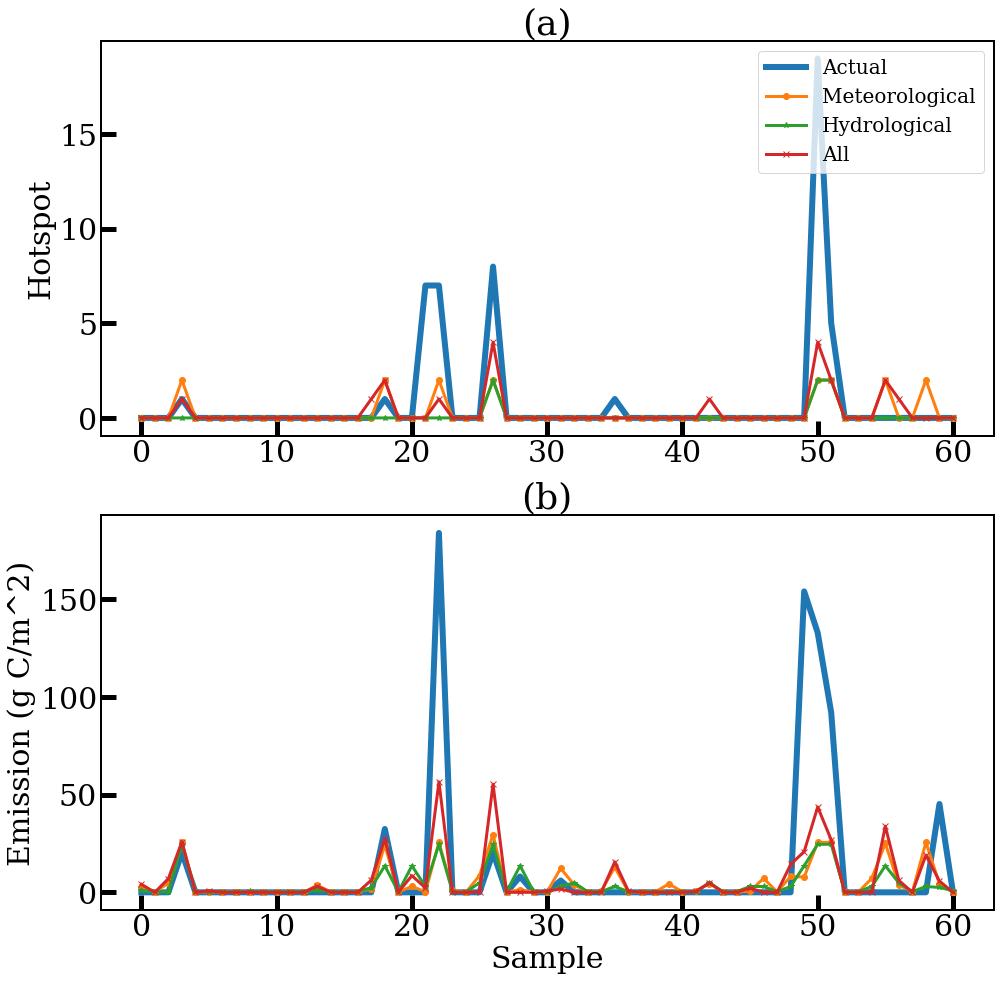

In [ ]:
plot_experiment(y_test, pred_lgbm_1, pred_lgbm_2, pred_lgbm_3)

In [ ]:
evaluate(y_test, pred_lgbm_1)

,MAE,NRMSE,CC
,,,
Hotspot,0.74,0.14,0.58
Emission,11.32,0.18,0.54


In [ ]:
evaluate(y_test, pred_lgbm_2)

,MAE,NRMSE,CC
,,,
Hotspot,0.70,0.14,0.77
Emission,10.45,0.18,0.70


In [ ]:
evaluate(y_test, pred_lgbm_3)

,MAE,NRMSE,CC
,,,
Hotspot,0.69,0.12,0.76
Emission,10.53,0.16,0.70


## NN

### Exp 1

Epoch 1/100
1/1 [==============================] - 1s 893ms/step - loss: 340.3775 - mse: 340.3775 - val_loss: 45.2300 - val_mse: 45.2300
Epoch 2/100
1/1 [==============================] - 0s 34ms/step - loss: 335.3718 - mse: 335.3718 - val_loss: 42.7290 - val_mse: 42.7290
Epoch 3/100
1/1 [==============================] - 0s 37ms/step - loss: 329.3159 - mse: 329.3159 - val_loss: 40.0057 - val_mse: 40.0057
Epoch 4/100
1/1 [==============================] - 0s 35ms/step - loss: 319.4974 - mse: 319.4974 - val_loss: 39.7736 - val_mse: 39.7736
Epoch 5/100
1/1 [==============================] - 0s 32ms/step - loss: 311.4465 - mse: 311.4465 - val_loss: 45.8560 - val_mse: 45.8560
Epoch 6/100
1/1 [==============================] - 0s 34ms/step - loss: 301.6049 - mse: 301.6049 - val_loss: 54.1871 - val_mse: 54.1871
Epoch 7/100
1/1 [==============================] - 0s 31ms/step - loss: 301.2317 - mse: 301.2317 - val_loss: 52.3169 - val_mse: 52.3169
Epoch 8/100
1/1 [==============================

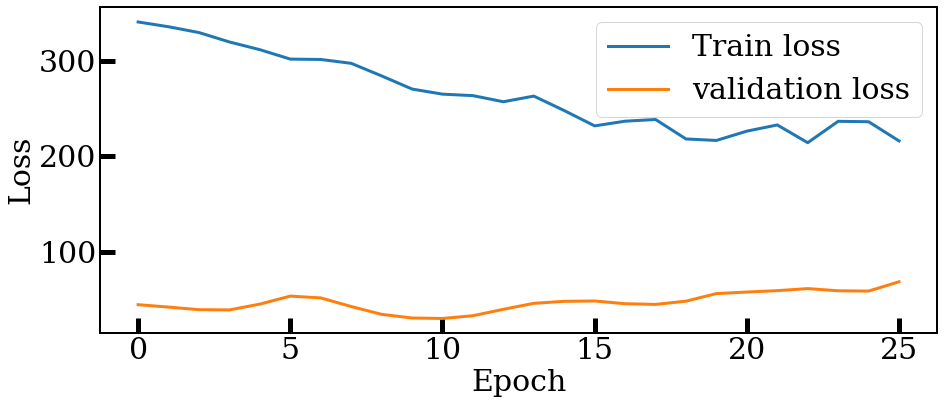

In [ ]:
# Model NN
model_nn_1 = build_nn(X_train_1)
history_1 = fit_nn(model_nn_1, X_train_1)
plot_history(history_1)

In [ ]:
pred_nn_1 = convert(model_nn_1.predict(X_test_1))

### Exp 2

Epoch 1/100
1/1 [==============================] - 1s 810ms/step - loss: 340.2574 - mse: 340.2574 - val_loss: 46.1608 - val_mse: 46.1608
Epoch 2/100
1/1 [==============================] - 0s 32ms/step - loss: 337.9924 - mse: 337.9924 - val_loss: 44.7656 - val_mse: 44.7656
Epoch 3/100
1/1 [==============================] - 0s 32ms/step - loss: 333.8873 - mse: 333.8873 - val_loss: 43.3155 - val_mse: 43.3155
Epoch 4/100
1/1 [==============================] - 0s 33ms/step - loss: 329.3882 - mse: 329.3882 - val_loss: 42.4202 - val_mse: 42.4202
Epoch 5/100
1/1 [==============================] - 0s 38ms/step - loss: 323.5115 - mse: 323.5115 - val_loss: 43.1547 - val_mse: 43.1547
Epoch 6/100
1/1 [==============================] - 0s 40ms/step - loss: 313.4378 - mse: 313.4378 - val_loss: 46.1220 - val_mse: 46.1220
Epoch 7/100
1/1 [==============================] - 0s 39ms/step - loss: 306.5562 - mse: 306.5562 - val_loss: 48.8908 - val_mse: 48.8908
Epoch 8/100
1/1 [==============================

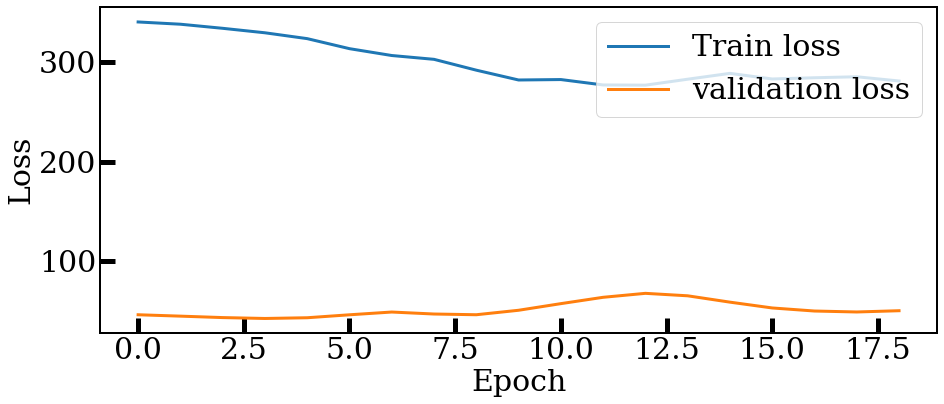

In [ ]:
# Model NN
model_nn_2 = build_nn(X_train_2)
history_2 = fit_nn(model_nn_2, X_train_2)
plot_history(history_2)

In [ ]:
pred_nn_2 = convert(model_nn_2.predict(X_test_2))

### Exp 3

Epoch 1/100
1/1 [==============================] - 1s 758ms/step - loss: 339.6094 - mse: 339.6094 - val_loss: 44.6761 - val_mse: 44.6761
Epoch 2/100
1/1 [==============================] - 0s 37ms/step - loss: 334.4776 - mse: 334.4776 - val_loss: 41.1216 - val_mse: 41.1216
Epoch 3/100
1/1 [==============================] - 0s 42ms/step - loss: 325.5775 - mse: 325.5775 - val_loss: 37.6560 - val_mse: 37.6560
Epoch 4/100
1/1 [==============================] - 0s 34ms/step - loss: 310.0497 - mse: 310.0497 - val_loss: 37.0169 - val_mse: 37.0169
Epoch 5/100
1/1 [==============================] - 0s 34ms/step - loss: 294.8690 - mse: 294.8690 - val_loss: 42.5282 - val_mse: 42.5282
Epoch 6/100
1/1 [==============================] - 0s 36ms/step - loss: 291.3012 - mse: 291.3012 - val_loss: 46.3842 - val_mse: 46.3842
Epoch 7/100
1/1 [==============================] - 0s 34ms/step - loss: 277.7098 - mse: 277.7098 - val_loss: 45.3829 - val_mse: 45.3829
Epoch 8/100
1/1 [==============================

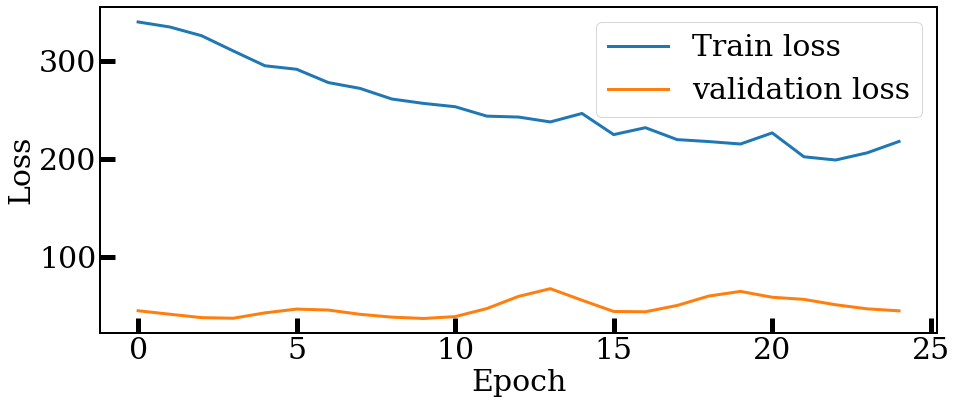

In [ ]:
# Model NN
model_nn_3 = build_nn(X_train_3)

history_3 = fit_nn(model_nn_3, X_train_3)
plot_history(history_3)

In [ ]:
pred_nn_3 = convert(model_nn_3.predict(X_test_3))

### Plot

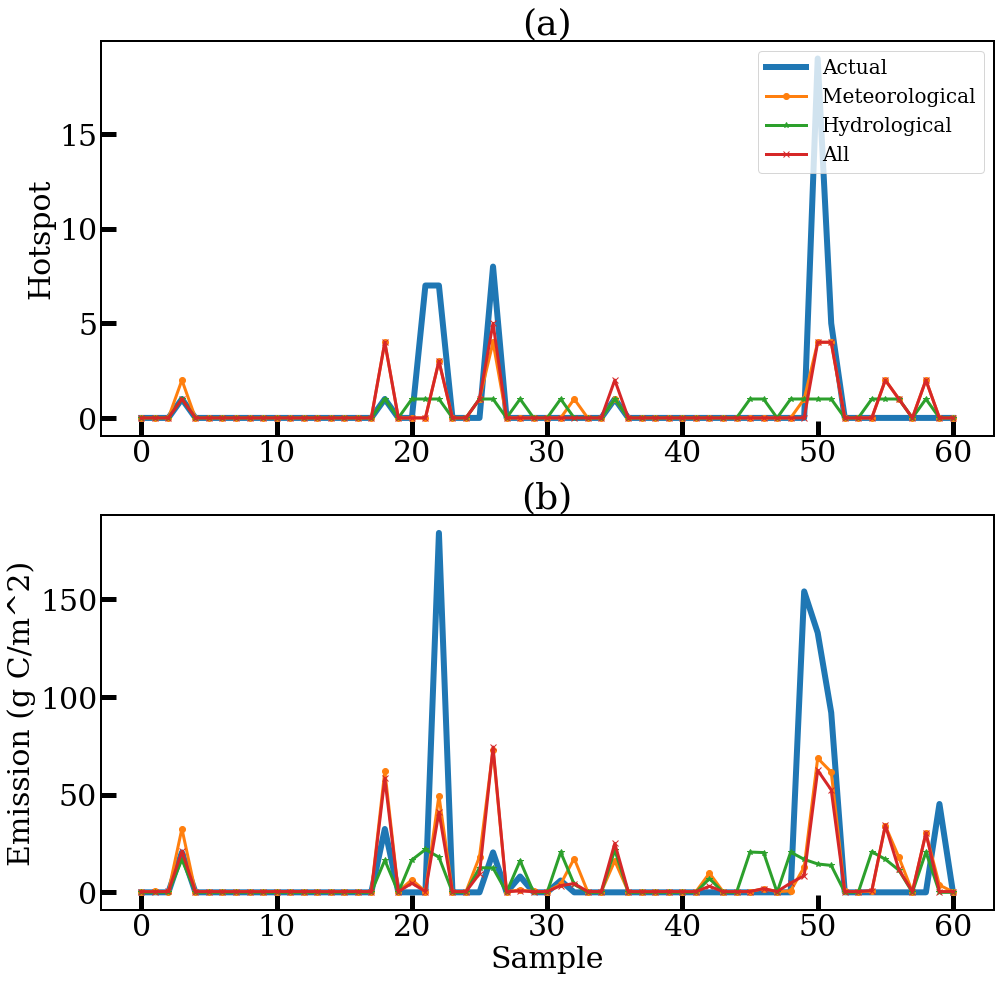

In [ ]:
plot_experiment(y_test, pred_nn_1, pred_nn_2, pred_nn_3)

In [ ]:
evaluate(y_test, pred_nn_1)

,MAE,NRMSE,CC
,,,
Hotspot,0.70,0.12,0.67
Emission,11.19,0.16,0.60


In [ ]:
evaluate(y_test, pred_nn_2)

,MAE,NRMSE,CC
,,,
Hotspot,0.87,0.15,0.40
Emission,13.29,0.19,0.35


In [ ]:
evaluate(y_test, pred_nn_3)

,MAE,NRMSE,CC
,,,
Hotspot,0.66,0.12,0.68
Emission,11.14,0.17,0.55


## Best Exp All Method
RF --> Exp 2

LightGBM --> Exp 3

NN --> Exp 3

In [ ]:
model_rf = model_rf_2
pred_rf = convert(model_rf.predict(X_test_2))

model_lgbm = model_lgbm_3
pred_lgbm = convert(model_lgbm.predict(X_test_3))

model_nn = model_nn_3
pred_nn = convert(model_nn.predict(X_test_3))

In [ ]:
ann_viz(model_nn, view=True, title='model_nn', filename='model_nn')

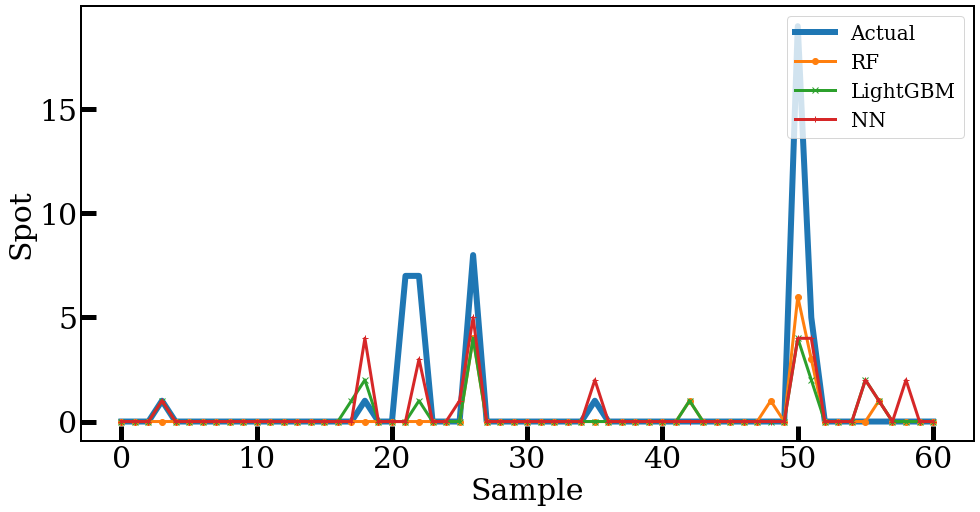

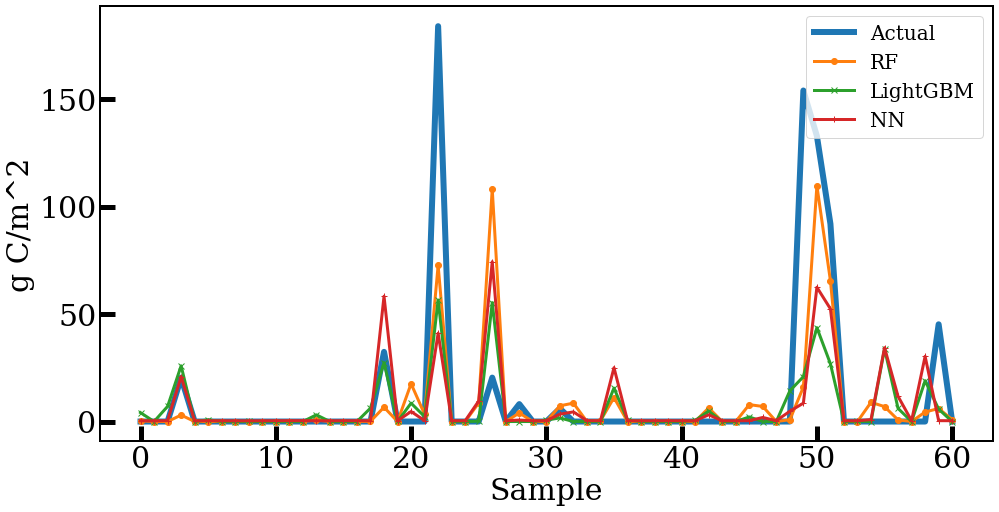

In [ ]:
plt.figure(figsize=(16, 8))
plt.plot(y_test[:,0], linewidth=6, label='Actual')
plt.plot(pred_rf[:,0], '-o', label='RF')
plt.plot(pred_lgbm[:,0], '-x', label='LightGBM')
plt.plot(pred_nn[:,0], '-+', label='NN')
plt.xlabel('Sample')
plt.ylabel('Spot')
plt.legend(fontsize = 20, loc = 'upper right')

plt.figure(figsize=(16, 8))
plt.plot(y_test[:,1], linewidth=6, label='Actual')
plt.plot(pred_rf[:,1], '-o', label='RF')
plt.plot(pred_lgbm[:,1], '-x', label='LightGBM')
plt.plot(pred_nn[:,1], '-+', label='NN')
plt.xlabel('Sample')
plt.ylabel('g C/m^2')
plt.legend(fontsize = 20, loc = 'upper right')

# Feature Importance

Find the important variables by using RandomForest.feature_importances_

## RF

In [ ]:
# Get numerical feature importances
rf_importances_0 = model_rf_3.estimators_[0].feature_importances_
rf_importances_1 = model_rf_3.estimators_[1].feature_importances_

print(np.round_(rf_importances_0,3))
print(np.round_(rf_importances_1,3))

[0.    0.614 0.012 0.259 0.065 0.004 0.047]
[0.    0.352 0.077 0.169 0.309 0.077 0.017]


## LightGBM

In [ ]:
# Get numerical feature importances
lgbm_importances_0 = model_lgbm_3.estimators_[0].feature_importances_
lgbm_importances_0 = [lgbm_importances_0[i]/sum(lgbm_importances_0) for i in range(len(pred_all))]

lgbm_importances_1 = model_lgbm_3.estimators_[1].feature_importances_
lgbm_importances_1 = [lgbm_importances_1[i]/sum(lgbm_importances_1) for i in range(len(pred_all))]

print(np.round_(lgbm_importances_0,3))
print(np.round_(lgbm_importances_1,3))

[0.002 0.178 0.206 0.188 0.181 0.107 0.137]
[0.    0.175 0.186 0.247 0.156 0.172 0.064]


## NN

In [ ]:
e = shap.KernelExplainer(model_nn_3, X_train_3)
shap_values = e.shap_values(X_test_3)

  0%|          | 0/61 [00:00<?, ?it/s]

In [ ]:
# Get numerical feature importances
nn_importances_0 = abs(shap_values[0]).mean(axis=0)
nn_importances_0 = [nn_importances_0[i]/sum(nn_importances_0) for i in range(len(pred_all))]

nn_importances_1 = abs(shap_values[1]).mean(axis=0)
nn_importances_1 = [nn_importances_1[i]/sum(nn_importances_1) for i in range(len(pred_all))]

print(np.round_(nn_importances_0,3))
print(np.round_(nn_importances_1,3))

[0.008 0.078 0.272 0.29  0.006 0.197 0.149]
[0.008 0.079 0.271 0.288 0.005 0.196 0.153]


## Best Model

In [ ]:
# Get numerical feature importances
best_importances_0 = model_rf_2.estimators_[0].feature_importances_
best_importances_1 = model_rf_2.estimators_[1].feature_importances_

print(np.round_(best_importances_0,3))
print(np.round_(best_importances_1,3))

[0.278 0.302 0.419]
[0.332 0.311 0.357]


## Plot

Text(0, 0.5, 'Importance')

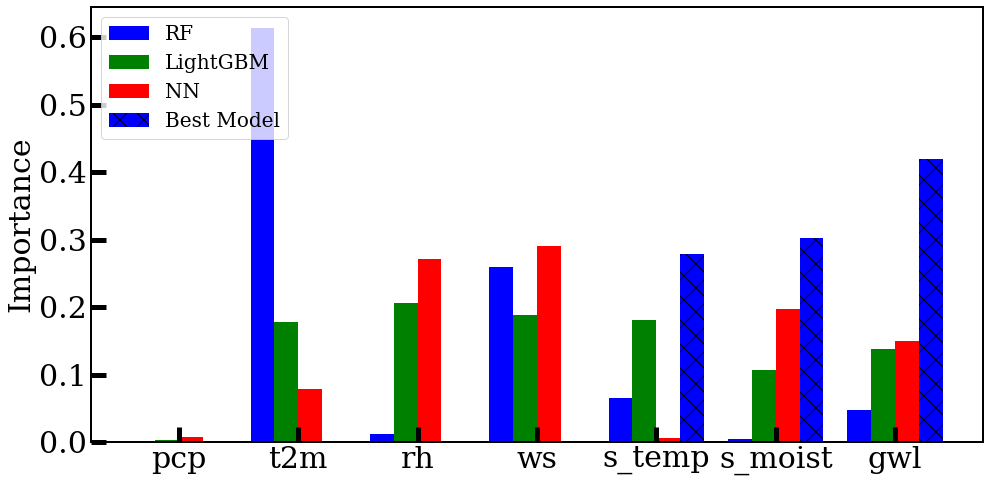

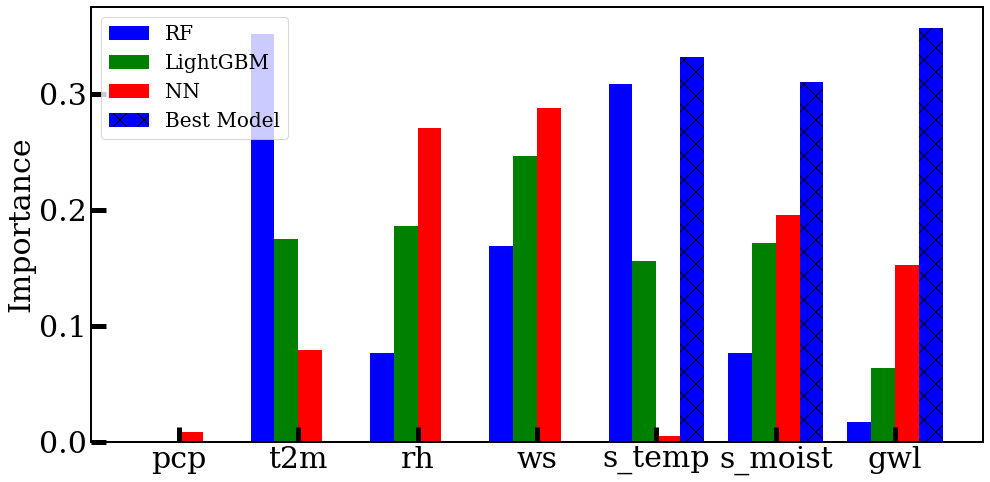

In [ ]:
x = np.arange(len(pred_all))
x_best = np.arange(len(pred_hydrological))

plt.figure(figsize=(16, 8))
plt.bar(x-0.3, rf_importances_0, width=0.2, color='b', align='center')
plt.bar(x-0.1, lgbm_importances_0, width=0.2, color='g', align='center')
plt.bar(x+0.1, nn_importances_0, width=0.2, color='r', align='center')
plt.bar(x_best+4.3, best_importances_0, width=0.2, color='b', hatch='x', align='center')

plt.legend(('RF', 'LightGBM', 'NN', 'Best Model'), fontsize = 20, loc = 'upper left')
plt.xticks(x, pred_all)
plt.ylabel('Importance')

plt.figure(figsize=(16, 8))
plt.bar(x-0.3, rf_importances_1, width=0.2, color='b', align='center')
plt.bar(x-0.1, lgbm_importances_1, width=0.2, color='g', align='center')
plt.bar(x+0.1, nn_importances_1, width=0.2, color='r', align='center')
plt.bar(x_best+4.3, best_importances_1, width=0.2, color='b', hatch='x', align='center')


plt.legend(('RF', 'LightGBM', 'NN', 'Best Model'), fontsize = 20, loc = 'upper left')
plt.xticks(x, pred_all)
plt.ylabel('Importance')